In [1]:
import pandas as pd

data = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [5]:
y_scores = model.predict_proba(X_test)[:,1]


In [6]:
y_scores

array([0.04953614, 0.17457598, 0.09361881, 0.25506885, 0.63547544,
       0.11671368, 0.06567023, 0.42188399, 0.04866172, 0.57563331,
       0.33875755, 0.41304766, 0.69854116, 0.19964149, 0.02001751,
       0.82471066, 0.86656925, 0.03101004, 0.25510704, 0.89492503,
       0.95246417, 0.83478816, 0.11740638, 0.44669903, 0.08923277,
       0.0688273 , 0.65117568, 0.41197875, 0.17860377, 0.28690155,
       0.24546297, 0.43904474, 0.00942529, 0.24260485, 0.35171265,
       0.96164606, 0.34360459, 0.80926014, 0.29380482, 0.0508316 ,
       0.18185164, 0.08671687, 0.42233336, 0.18738035, 0.03011578,
       0.03949078, 0.24740821, 0.42784702, 0.10529277, 0.37970704,
       0.99355928, 0.10665836, 0.39100545, 0.76883113, 0.36866729,
       0.45776991, 0.95035238, 0.41990462, 0.39153693, 0.04376   ,
       0.37295079, 0.90128751, 0.88176468, 0.88842753, 0.33083729,
       0.06930532, 0.9526512 , 0.20057864, 0.260557  , 0.35464146,
       0.10359002, 0.08168553, 0.45043617, 0.09221098, 0.08648

In [8]:
from sklearn.metrics import roc_auc_score

fpr,tpr,thresholds = roc_curve(y_test, y_scores)

In [9]:
thresholds


array([       inf, 0.99355928, 0.9526512 , 0.95246417, 0.82471066,
       0.76883113, 0.76198112, 0.68385812, 0.67529148, 0.67422748,
       0.65117568, 0.65085312, 0.63547544, 0.58630057, 0.57563331,
       0.56974552, 0.52514581, 0.47017119, 0.46131937, 0.45043617,
       0.43904474, 0.43865745, 0.42233336, 0.41990462, 0.41304766,
       0.41197875, 0.40477801, 0.37970704, 0.36866729, 0.31020305,
       0.30880354, 0.27772349, 0.27205111, 0.25510704, 0.25506885,
       0.24740821, 0.24546297, 0.23665336, 0.22887288, 0.18185164,
       0.17860377, 0.17457598, 0.1732547 , 0.14638332, 0.14074927,
       0.11671368, 0.11494479, 0.11000892, 0.10665836, 0.08923277,
       0.08671687, 0.02001751, 0.01931547, 0.00160784])

In [10]:
import plotly.graph_objects as go
import numpy as np

#Generate a trace for ROC curve
trace0 = go.Scatter(
    x = fpr,
    y = tpr,
    mode = 'lines',
    name = 'ROC Curve'
)

#Only lable every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) %n == 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)


# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=False
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()

In [11]:
# Assume that fpr, tpr, thresholds have already been calculated
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print("Optimal threshold is:", optimal_threshold)


Optimal threshold is: 0.36866729149373506


In [12]:
import plotly.graph_objects as go
import numpy as np
from sklearn.metrics import roc_auc_score

# Assuming fpr, tpr, thresholds are already calculated as before
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Calculate the AUC (Area Under the Curve)
roc_auc = roc_auc_score(y_test, y_scores)

# Generate a trace for ROC curve
trace0 = go.Scatter(
    x=fpr,
    y=tpr,
    mode='lines',
    name=f'ROC curve (Area = {roc_auc:.2f})'
)

# Only label every nth point to avoid cluttering
n = 10
indices = np.arange(len(thresholds)) % n == 0  # Choose indices where index mod n is 0

trace1 = go.Scatter(
    x=fpr[indices],
    y=tpr[indices],
    mode='markers+text',
    name='Threshold points',
    text=[f"Thr={thr:.2f}" for thr in thresholds[indices]],
    textposition='top center'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


In [13]:
import numpy as np
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler

# Assuming that X_train, X_test, y_train, y_test are already defined

# SVM requires feature scaling for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_scores = lr_model.predict_proba(X_test)[:,1]

# SVM model
svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_scores = svm_model.predict_proba(X_test_scaled)[:,1]

# Generate ROC curve data for logistic regression model
lr_fpr, lr_tpr, lr_thresholds = roc_curve(y_test, lr_scores)
lr_auc = roc_auc_score(y_test, lr_scores)

# Generate ROC curve data for SVM model
svm_fpr, svm_tpr, svm_thresholds = roc_curve(y_test, svm_scores)
svm_auc = roc_auc_score(y_test, svm_scores)

# Generate a trace for the Logistic Regression ROC curve
trace0 = go.Scatter(
    x=lr_fpr,
    y=lr_tpr,
    mode='lines',
    name=f'Logistic Regression (Area = {lr_auc:.2f})'
)

# Generate a trace for the SVM ROC curve
trace1 = go.Scatter(
    x=svm_fpr,
    y=svm_tpr,
    mode='lines',
    name=f'SVM (Area = {svm_auc:.2f})'
)

# Diagonal line
trace2 = go.Scatter(
    x=[0, 1],
    y=[0, 1],
    mode='lines',
    name='Random (Area = 0.5)',
    line=dict(dash='dash')
)

data = [trace0, trace1, trace2]

# Define layout with square aspect ratio
layout = go.Layout(
    title='Receiver Operating Characteristic',
    xaxis=dict(title='False Positive Rate'),
    yaxis=dict(title='True Positive Rate'),
    autosize=False,
    width=800,
    height=800,
    showlegend=True
)

# Define figure and add data
fig = go.Figure(data=data, layout=layout)

# Show figure
fig.show()


Softmax Regression

In [14]:
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [18]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])
df.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
17,5.1,3.5,1.4,0.3,0
143,6.8,3.2,5.9,2.3,2
88,5.6,3.0,4.1,1.3,1
11,4.8,3.4,1.6,0.2,0
120,6.9,3.2,5.7,2.3,2
70,5.9,3.2,4.8,1.8,1
135,7.7,3.0,6.1,2.3,2
126,6.2,2.8,4.8,1.8,2
117,7.7,3.8,6.7,2.2,2
133,6.3,2.8,5.1,1.5,2


In [19]:
df = df[['sepal_length','petal_length','species']]
df.head()

,sepal_length,petal_length,species
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0


In [20]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
clf = LogisticRegression(multi_class='multinomial')
clf.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



LogisticRegression(multi_class='multinomial')

In [21]:
y_pred = clf.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.9666666666666667


In [23]:
pd.DataFrame(confusion_matrix(y_test,y_pred))

,0,1,2
0,14,0,0
1,0,7,1
2,0,0,8


In [27]:
# prediction
query = np.array([[3.4,2.7]])
clf.predict_proba(query) #gives output of probabilty

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



array([[7.25865651e-01, 2.73720718e-01, 4.13631316e-04]])

In [25]:
clf.predict(query)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



array([0])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



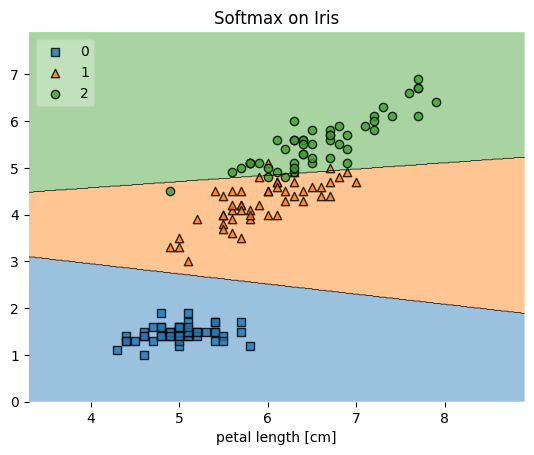

In [26]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values,y.values, clf, legend =2)

#Adding axes notations
plt.xlabel('sepal length [cm]')
plt.xlabel('petal length [cm]')
plt.title('Softmax on Iris')

plt.show()

Logistic Regression Hyperparameters

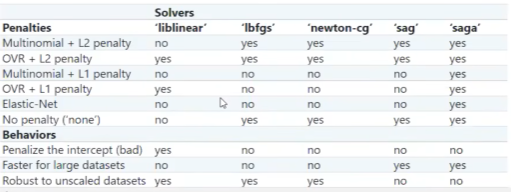